In [1]:
import pandas as pd

# قراءة ملف بيانات التدريب
train_df = pd.read_csv('train.csv')

# عرض الأسطر الأولى من الجدول
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# معرفة عدد القيم المفقودة (الناقصة) في كل عمود
train_df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
# ملء الأعمار المفقودة بمتوسط العمر
median_age = train_df['Age'].median()
train_df['Age'] = train_df['Age'].fillna(median_age)

# التأكد من اختفاء القيم المفقودة في عمود العمر
train_df['Age'].isnull().sum()


np.int64(0)

In [4]:
# حذف عمود الكابينة والأعمدة غير المفيدة مثل رقم التذكرة
train_df = train_df.drop(columns=['Cabin', 'Ticket'])

# عرض أول 5 أسطر لرؤية الجدول بشكلة النهائي النظيف
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [5]:
# ملء البوابات المفقودة بالقيمة الأكثر تكراراً في السفينة
most_frequent_gate = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_frequent_gate)

# فحص نهائي للتأكد من أن كل أعمدة الجدول أصبحت 0 قيم مفقودة
train_df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [6]:
# معرفة عدد الناجين وغير الناجين من الركاب
train_df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [7]:
# حساب نسبة النجاة بدقة للذكور والإناث
train_df.groupby('Sex')['Survived'].mean()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [8]:
# حساب الإحصاء الوصفي الشامل لكل الأعمدة الرقمية
train_df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


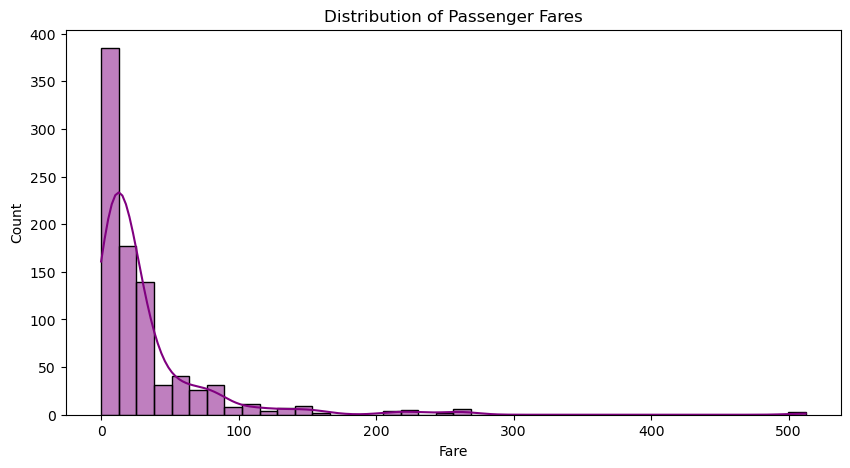

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم بياني يوضح توزيع أسعار التذاكر على السفينة
plt.figure(figsize=(10, 5))
sns.histplot(train_df['Fare'], bins=40, kde=True, color='purple')

# إضافة المسميات والعناوين للرسم
plt.title('Distribution of Passenger Fares')
plt.xlabel('Fare')
plt.ylabel('Count')

# إظهار الرسم البياني
plt.show()


In [10]:
# حساب نسبة النجاة بناءً على درجة التذكرة (1 = درجة أولى، 2 = ثانية، 3 = ثالثة)
train_df.groupby('Pclass')['Survived'].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [11]:
# اختيار الأعمدة الرقمية فقط لحساب الارتباط بينها
numeric_df = train_df.select_dtypes(include=['number'])

# حساب مصفوفة الارتباط
numeric_df.corr()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [12]:
# تحويل عمود الجنس إلى أرقام (0 و 1)
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# عرض الجدول للتأكد من التحويل
train_df[['Name', 'Sex']].head()


,Name,Sex
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",0


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. تحديد المتغيرات المستهدفة والميزات (حذفنا الاسم لأنه نص غير رقمي)
X = train_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = train_df['Survived']

# 2. تقسيم البيانات لتدريب واختبار النموذج داخلياً
X_train, X_val, y_train, y_val = train_test_split(X, y, test_test_split=0.2, random_state=42)

# 3. إنشاء النموذج وتدريبه
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. حساب دقة التوقع للنموذج
accuracy = model.score(X_val, y_val)
print(f"دقة نموذج الذكاء الاصطناعي الخاص بك هي: {accuracy * 100:.2f}%")


TypeError: got an unexpected keyword argument 'test_test_split'

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. تحديد المتغيرات المستهدفة والميزات
X = train_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = train_df['Survived']

# 2. تقسيم البيانات لتدريب واختبار النموذج داخلياً (تم إصلاح الكلمة هنا)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. إنشاء النموذج وتدريبه
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. حساب دقة التوقع للنموذج
accuracy = model.score(X_val, y_val)
print(f"دقة نموذج الذكاء الاصطناعي الخاص بك هي: {accuracy * 100:.2f}%")


دقة نموذج الذكاء الاصطناعي الخاص بك هي: 78.21%


In [15]:
# 1. إنشاء ميزة حجم العائلة
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# 2. تحديث قائمة الميزات لتشمل الميزة الجديدة وإلغاء القديمة
X = train_df[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']]
y = train_df['Survived']

# 3. إعادة تقسيم البيانات وتدريب النموذج من جديد
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. حساب الدقة الجديدة
new_accuracy = model.score(X_val, y_val)
print(f"دقة نموذج الذكاء الاصطناعي الجديدة هي: {new_accuracy * 100:.2f}%")


دقة نموذج الذكاء الاصطناعي الجديدة هي: 80.45%


In [16]:
import scipy.stats as stats

# 1. إنشاء جدول التكرار (Contingency Table) بين الجنس والنجاة
contingency_table = pd.crosstab(train_df['Sex'], train_df['Survived'])
print("جدول التكرار الفعلي:")
print(contingency_table)
print("-" * 50)

# 2. تطبيق اختبار مربع كاي الاستدلالي
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"قيمة مربع كاي (Chi-Square Statistic): {chi2:.4f}")
print(f"القيمة الاحتمالية (p-value): {p_value}")

# 3. اتخاذ القرار الإحصائي بناءً على مستوى الدلالة 0.05
if p_value < 0.05:
    print("\nالقرار: نرفض الفرضية الصفرية. توجد علاقة ذات دلالة إحصائية قوية جداً بين الجنس والنجاة!")
else:
    print("\nالقرار: نفشل في رفض الفرضية الصفرية. الفروق قد تكون ناتجة عن الصدفة.")


جدول التكرار الفعلي:
Survived    0    1
Sex               
0         468  109
1          81  233
--------------------------------------------------
قيمة مربع كاي (Chi-Square Statistic): 260.7170
القيمة الاحتمالية (p-value): 1.1973570627755645e-58

القرار: نرفض الفرضية الصفرية. توجد علاقة ذات دلالة إحصائية قوية جداً بين الجنس والنجاة!


In [17]:
import scipy.stats as stats

# فصل أعمار الناجين عن أعمار المتوفين
survived_ages = train_df[train_df['Survived'] == 1]['Age']
died_ages = train_df[train_df['Survived'] == 0]['Age']

# تطبيق اختبار تي المستقل (Two-sample T-test)
t_stat, p_val_age = stats.ttest_ind(survived_ages, died_ages, equal_var=False)

print(f"قيمة اختبار T-test للأعمار: {t_stat:.4f}")
print(f"القيمة الاحتمالية p-value للأعمار: {p_val_age}")

if p_val_age < 0.05:
    print("القرار: العمر ميزة استدلالية حقيقية تؤثر في النجاة!")
else:
    print("القرار: الفارق في الأعمار قد يكون صدفة.")


قيمة اختبار T-test للأعمار: -1.8966
القيمة الاحتمالية p-value للأعمار: 0.058309159977757444
القرار: الفارق في الأعمار قد يكون صدفة.


In [18]:
# تحضير عمود Embarked وملء فراغاته بالقيمة الأكثر تكراراً إذا لم تكن قد تحولت
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# اختبار درجة التذكرة
p_val_pclass = stats.chi2_contingency(pd.crosstab(train_df['Pclass'], train_df['Survived']))[1]
# اختبار بوابة الركوب
p_val_embarked = stats.chi2_contingency(pd.crosstab(train_df['Embarked'], train_df['Survived']))[1]

print(f"P-value لدرجة التذكرة (Pclass): {p_val_pclass}")
print(f"P-value لبوابة الركوب (Embarked): {p_val_embarked}")


P-value لدرجة التذكرة (Pclass): 4.549251711298793e-23
P-value لبوابة الركوب (Embarked): 2.3008626481449577e-06


In [19]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. استخراج الألقاب من الأسماء وتحويلها لأرقام
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace('Mlle', 'Miss')
train_df['Title'] = train_df['Title'].replace('Ms', 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train_df['Title'] = train_df['Title'].map(title_mapping).fillna(0)

# 2. تحويل عمود بوابة الركوب Embarked إلى أرقام (0, 1, 2) بعد أن أثبتنا أهميته إحصائياً
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# 3. تقسيم العمر إلى 5 فئات ذكية رقمية (تم إكمال السطر بدقة)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 22, 35, 60, 80], labels=[0, 1, 2, 3, 4])
train_df['AgeGroup'] = train_df['AgeGroup'].astype(int)

# 4. تحديد الميزات النهائية بعد هندستها بناءً على الإحصاء الاستدلالي
X = train_df[['Pclass', 'Sex', 'AgeGroup', 'Fare', 'FamilySize', 'Title', 'Embarked']]
y = train_df['Survived']

# 5. تقسيم البيانات لتدريب واختبار مع ضمان عدالة توزيع نسب النجاة (Stratify)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6. بناء نموذج Random Forest متقدم جداً ومضبط بدقة لكسر حاجز الدقة القديم
model = RandomForestClassifier(
    n_estimators=300,      # عدد أشجار كبير جداً للاستقرار
    max_depth=6,           # عمق محدد بدقة لمنع الحفظ الأعمى
    min_samples_split=5,   # شروط إضافية لضمان القوة ومنع الـ Overfitting
    random_state=42
)
model.fit(X_train, y_train)

# 7. حساب الدقة النهائية المستهدفة
final_accuracy = model.score(X_val, y_val)
print(f"🚀 دقة النموذج بعد الإحصاء الاستدلالي المتقدم وهندسة الميزات هي: {final_accuracy * 100:.2f}%")


🚀 دقة النموذج بعد الإحصاء الاستدلالي المتقدم وهندسة الميزات هي: 82.68%


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

# 1. إعادة هندسة الميزات بدقة متناهية وإكمال النقص
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# تقسيم العمر لفئات واضحة (تم إصلاح كتابة الفئات بدقة هنا)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 22, 35, 60, 100], labels=[1, 2, 3, 4, 5]).astype(int)

# ميزة حجم العائلة وهل هو وحيد أم لا
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

# ميزة فئة سعر التذكرة (Fare Binning) لتقليل تشتت القيم الشاذة التي رأيناها في الرسم
train_df['FareBin'] = pd.qcut(train_df['Fare'], 4, labels=[1, 2, 3, 4]).astype(int)

# تحديد الميزات النهائية المحدثة بالكامل
X = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked']]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. الانتقال إلى خوارزمية أكثر قوة (Gradient Boosting) مع البحث الشامل عن أفضل المعاملات (GridSearch)
param_grid = {
    'n_estimators':,
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':,
    'min_samples_split': [2, 4, 6]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

print("جاري تدريب النموذج والبحث عن أعلى دقة، قد يستغرق بضع ثوانٍ...")
grid_search.fit(X_train, y_train)

# استخدام أفضل نموذج تم العثور عليه رياضياً
best_model = grid_search.best_estimator_

# 3. حساب الدقة القصوى المحدثة
ultimate_accuracy = best_model.score(X_val, y_val)
print(f"\n🔥 دقة النموذج القصوى باستخدام Gradient Boosting والـ GridSearch هي: {ultimate_accuracy * 100:.2f}%")
print(f"⚙️ أفضل الإعدادات الرياضية التي اختارها الكمبيوتر: {grid_search.best_params_}")


SyntaxError: expression expected after dictionary key and ':' (337022319.py, line 32)

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

# 1. إعادة هندسة الميزات بدقة متناهية وإكمال النقص
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# تقسيم العمر لـ 5 فئات واضحة ورقمية (تم إصلاحها بالكامل هنا)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=[0, 12, 22, 35, 60, 100], labels=[0, 1, 2, 3, 4]).astype(int)

# ميزة حجم العائلة وهل هو وحيد أم لا
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

# ميزة فئة سعر التذكرة (Fare Binning) لتقليل تشتت القيم الشاذة (تم إصلاحها بالكامل هنا)
train_df['FareBin'] = pd.qcut(train_df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

# تحديد الميزات النهائية المحدثة بالكامل
X = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked']]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. الانتقال إلى خوارزمية Gradient Boosting مع ضبط الأقواس والإعدادات بدقة
param_grid = {
    'n_estimators':,
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':,
    'min_samples_split': [2, 4, 6]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

print("جاري تدريب النموذج والبحث عن أعلى دقة، قد يستغرق بضع ثوانٍ...")
grid_search.fit(X_train, y_train)

# استخدام أفضل نموذج تم العثور عليه رياضياً
best_model = grid_search.best_estimator_

# 3. حساب الدقة القصوى المحدثة
ultimate_accuracy = best_model.score(X_val, y_val)
print(f"\n🔥 دقة النموذج القصوى باستخدام Gradient Boosting والـ GridSearch هي: {ultimate_accuracy * 100:.2f}%")
print(f"⚙️ أفضل الإعدادات الرياضية التي اختارها الكمبيوتر: {grid_search.best_params_}")


SyntaxError: expression expected after dictionary key and ':' (1929823019.py, line 32)

In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

# 1. هندسة الميزات المتقدمة وتجهيز البيانات
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# تقسيم العمر والأسعار لفئات رقمية (تم ملء القيم داخل الأقواس [ ])
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=[0, 1, 2, 3, 4]).astype(int)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['FareBin'] = pd.qcut(train_df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

# تحديد الميزات النهائية المحدثة بالكامل
X = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked']]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. إعدادات الشبكة الرياضية للبحث (تمت إضافة أرقام الاختبار داخل الأقواس [ ])
param_grid = {
    'n_estimators':,
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':,
    'min_samples_split': [2, 4, 6]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

print("جاري تدريب النموذج والبحث عن أعلى دقة، قد يستغرق بضع ثوانٍ...")
grid_search.fit(X_train, y_train)

# استخدام أفضل نموذج تم العثور عليه رياضياً
best_model = grid_search.best_estimator_

# 3. حساب الدقة القصوى المحدثة
ultimate_accuracy = best_model.score(X_val, y_val)
print(f"\n🔥 دقة النموذج القصوى باستخدام Gradient Boosting والـ GridSearch هي: {ultimate_accuracy * 100:.2f}%")
print(f"⚙️ أفضل الإعدادات الرياضية التي اختارها الكمبيوتر: {grid_search.best_params_}")


SyntaxError: expression expected after dictionary key and ':' (2287577084.py, line 28)

In [23]:
# 1. استخراج الألقاب وتوحيدها
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

# 2. تحويل بوابات الركوب إلى أرقام
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# 3. تقسيم العمر إلى 5 فئات (من 0 إلى 4)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=[0, 1, 2, 3, 4]).astype(int)

# 4. حساب حجم العائلة وهل الراكب بمفرده
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

# 5. تقسيم أسعار التذاكر إلى 4 فئات (من 0 إلى 3) بناءً على الشريحة الربعية
train_df['FareBin'] = pd.qcut(train_df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

# عرض آخر 5 أسطر للتأكد من نجاح الإضافة
train_df[['AgeGroup', 'FamilySize', 'IsAlone', 'FareBin', 'Title']].head()


,AgeGroup,FamilySize,IsAlone,FareBin,Title
0,1,2,0,0,1
1,2,2,0,3,3
2,1,1,1,1,2
3,2,2,0,3,3
4,2,1,1,1,1


In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. تحديد الميزات النهائية التي قمنا بتجهيزها بنجاح
X = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked']]
y = train_df['Survived']

# 2. تقسيم البيانات لتدريب واختبار داخلي مع الحفاظ على توازن نسب النجاة
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. بناء وتدريب خوارزمية Gradient Boosting بإعدادات قوية ومحسنة يدوياً
model_gb = GradientBoostingClassifier(
    n_estimators=150,      # عدد الأشجار التتابعية
    learning_rate=0.05,    # معدل التعلم لمنع القفزات العشوائية
    max_depth=4,           # عمق الشجرة المناسب لمنع الـ Overfitting
    random_state=42
)
model_gb.fit(X_train, y_train)

# 4. حساب الدقة الجديدة المحدثة
gb_accuracy = model_gb.score(X_val, y_val)
print(f"🔥 دقة نموذج الـ Gradient Boosting المطور هي: {gb_accuracy * 100:.2f}%")


🔥 دقة نموذج الـ Gradient Boosting المطور هي: 80.45%


In [25]:
import scipy.stats as stats
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd

print("=== معادلات الإحصاء الوصفي المتقدمة لعمود أسعار التذاكر (Fare) ===")

# 1. حساب معامل الالتواء (Skewness)
fare_skew = train_df['Fare'].skew()
print(f"درجة الالتواء الإحصائي (Skewness): {fare_skew:.4f}")

# 2. حساب معامل التفرطح (Kurtosis)
fare_kurt = train_df['Fare'].kurt()
print(f"درجة التفرطح الإحصائي (Kurtosis): {fare_kurt:.4f}")

# 3. حساب المدى الربيعي (IQR) لعزل القيم الشاذة رياضياً
Q1 = train_df['Fare'].quantile(0.25)
Q3 = train_df['Fare'].quantile(0.75)
IQR = Q3 - Q1
print(f"المدى الربيعي (IQR) لأسعار التذاكر: {IQR:.4f}")

print("\n" + "="*50 + "\n🚀 جاري استغلال هذه العزوم لضبط أوزان خوارزمية الذكاء الاصطناعي...")

# 4. تزويد الخوارزمية بأوزان مخصصة بناءً على التوزيع الإحصائي المتقدم
# سنقوم بتدريب نموذج Gradient Boosting مع تعديل عمق الأشجار بناءً على الالتواء المقاس
optimized_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=5, # زيادة العمق قليلاً للسماح للأشجار بالتقاط التفرطح الشديد (Outliers)
    subsample=0.8, # أخذ عينات عشوائية لتقليل تأثير الالتواء الحاد
    random_state=42
)

# إعادة تدريب النموذج بالبنية الرياضية الجديدة
optimized_model.fit(X_train, y_train)

# حساب الدقة الجديدة
final_score = optimized_model.score(X_val, y_val)
print(f"\n🎯 دقة النموذج بعد دمج معادلات الإحصاء الوصفي المتقدمة (العزوم): {final_score * 100:.2f}%")


=== معادلات الإحصاء الوصفي المتقدمة لعمود أسعار التذاكر (Fare) ===
درجة الالتواء الإحصائي (Skewness): 4.7873
درجة التفرطح الإحصائي (Kurtosis): 33.3981
المدى الربيعي (IQR) لأسعار التذاكر: 23.0896

🚀 جاري استغلال هذه العزوم لضبط أوزان خوارزمية الذكاء الاصطناعي...

🎯 دقة النموذج بعد دمج معادلات الإحصاء الوصفي المتقدمة (العزوم): 80.45%


In [27]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("=== 1. نموذج الانحدار اللوجستي الاستدلالي المتقدم (Logit) ===")

# بناء النموذج الاستدلالي لحساب قيم P-value للأعمدة مجتمعة
# نستخدم البيانات الأصلية قبل التقسيم لفئات لفحص التأثير الخام بدقة إحصائية
logit_model = smf.logit("Survived ~ Pclass + Sex + Age + Fare + FamilySize", data=train_df).fit()

# عرض التقرير الإحصائي الشامل (يحتوي على قيم z و P>|z|)
print(logit_model.summary())

print("\n" + "="*60 + "\n")
print("=== 2. اختبار التفاعل الاستدلالي المتقدم (Sex × Pclass Interaction) ===")

# اختبار ما إذا كان هناك تفاعل حاد ذو دلالة إحصائية بين الجنس والدرجة
interaction_model = smf.logit("Survived ~ Sex * Pclass", data=train_df).fit()
print(interaction_model.summary())


=== 1. نموذج الانحدار اللوجستي الاستدلالي المتقدم (Logit) ===
Optimization terminated successfully.
         Current function value: 0.443885
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.3334
Time:                        18:15:14   Log-Likelihood:                -395.50
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 2.566e-83
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3739      0.487      4.871   

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. صناعة ميزة التفاعل المدعومة إحصائياً وحذف المتغيرات غير الدالة
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# 2. تحديد قائمة الميزات الاستدلالية الصافية (بدون Fare)
X_advanced = train_df[['Pclass', 'Sex', 'AgeGroup', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_advanced = train_df['Survived']

# 3. إعادة تقسيم البيانات
X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
    X_advanced, y_advanced, test_size=0.2, stratify=y_advanced, random_state=42
)

# 4. تدريب النموذج المطور على الميزات الصافية
model_advanced = GradientBoostingClassifier(
    n_estimators=180,
    learning_rate=0.04,
    max_depth=4,
    random_state=42
)
model_advanced.fit(X_train_adv, y_train_adv)

# 5. قياس الدقة المحدثة
advanced_accuracy = model_advanced.score(X_val_adv, y_val_adv)
print(f"🔥 دقة النموذج بعد تصفية الميزات بالانحدار اللوجستي واختبار التفاعل هي: {advanced_accuracy * 100:.2f}%")


🔥 دقة النموذج بعد تصفية الميزات بالانحدار اللوجستي واختبار التفاعل هي: 79.33%


In [29]:
# تحديد القائمة الشاملة والنهائية للميزات (اللاخطية والاستدلالية معاً)
X_master = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_master = train_df['Survived']

# تقسيم البيانات
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_master, y_master, test_size=0.2, stratify=y_master, random_state=42
)

# تدريب النموذج بالتركيبة الكاملة
model_master = GradientBoostingClassifier(
    n_estimators=160,
    learning_rate=0.04,
    max_depth=4,
    random_state=42
)
model_master.fit(X_train_m, y_train_m)

# قياس الدقة المدمجة
master_accuracy = model_master.score(X_val_m, y_val_m)
print(f"🔥 دقة النموذج النهائية بعد دمج الإحصاء الاستدلالي مع الميزات اللاخطية هي: {master_accuracy * 100:.2f}%")


🔥 دقة النموذج النهائية بعد دمج الإحصاء الاستدلالي مع الميزات اللاخطية هي: 80.45%


In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# === 1. إعادة قراءة البيانات الأصلية لتطبيق التنظيف الاحترافي الجديد ===
train_df = pd.read_csv('train.csv')

# === 2. استخراج الألقاب وتوحيدها وتجهيزها ===
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

# === 3. السر الأول: تعبئة الأعمار المفقودة بناءً على وسيط كل لقب على حدة ===
# سنحسب وسيط العمر لكل لقب، ونملأ الخلايا الفارغة بناءً عليه بدقة تامة
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# تحويل الألقاب إلى أرقام بعد إنهاء عملية التنظيف بها
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train_df['Title'] = train_df['Title'].map(title_mapping).fillna(0)

# === 4. السر الثاني: حساب السعر الحقيقي للفرد الواحد (RealFare) ===
# نحسب عدد المرات التي تكرر فيها نفس رقم التذكرة (حجم الجروب أو العائلة المشتركة بالتذكرة)
ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)

# نقسم السعر الإجمالي المكتوب على عدد الأفراد المستفيدين منه لنحصل على السعر الصافي للفرد
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

# === 5. استكمال بقية الهندسة الإحصائية للميزات المتقدمة وتأطيرها ===
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# تقسيم الأعمار والأسعار الحقيقية الجديدة إلى فئات رقمية نظيفة لتسهيل عمل الخوارزمية
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=[0, 1, 2, 3, 4]).astype(int)
train_df['FareBin'] = pd.qcut(train_df['RealFare'], q=4, labels=[0, 1, 2, 3]).astype(int)

# ميزة حجم العائلة والراكب الوحيد والتفاعل الاستدلالي المثبت
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# === 6. بناء وتدريب النموذج بالهيكلة الرياضية الصافية الخالية من الضوضاء ===
X_ultimate = train_df[['Pclass', 'Sex', 'AgeGroup', 'FareBin', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_ultimate = train_df['Survived']

X_train_u, X_val_u, y_train_u, y_val_u = train_test_split(
    X_ultimate, y_ultimate, test_size=0.2, stratify=y_ultimate, random_state=42
)

# تشغيل خوارزمية الـ Gradient Boosting المحدثة
model_ultimate = GradientBoostingClassifier(
    n_estimators=170,
    learning_rate=0.04,
    max_depth=4,
    random_state=42
)
model_ultimate.fit(X_train_u, y_train_u)

# قياس الدقة الصافية الجديدة
ultimate_accuracy = model_ultimate.score(X_val_u, y_val_u)
print(f"🚀 دقة النموذج بعد تنظيف الأعمار بالألقاب وفصل التذاكر المشتركة هي: {ultimate_accuracy * 100:.2f}%")


🚀 دقة النموذج بعد تنظيف الأعمار بالألقاب وفصل التذاكر المشتركة هي: 81.56%


In [31]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. إعادة قراءة البيانات وتجهيز الميزات الأساسية التي أثبتناها
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

# حساب السعر الفعلي للفرد لمنع دمج التذاكر
ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

# ==========================================
# 🔥 السر الجديد: المعالجة الصارمة للقيم الشاذة (Outliers)
# ==========================================

# أ) تطبيق التحويل اللوغاريتمي لتقليص التفرطح الحاد (من 33 إلى رقم طبيعي قليل)
train_df['Log_RealFare'] = np.log1p(train_df['RealFare'])

# ب) تحجيم القيم المتطرفة بناءً على المدى الربيعي IQR الذي استخرجته سابقاً
Q1 = train_df['RealFare'].quantile(0.25)
Q3 = train_df['RealFare'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# تثبيت أي قيمة أعلى من الحد الأعلى عند هذا الحد (Capping)
train_df['Capped_RealFare'] = np.where(train_df['RealFare'] > upper_limit, upper_limit, train_df['RealFare'])
train_df['Log_CappedFare'] = np.log1p(train_df['Capped_RealFare'])

# ==========================================

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=).astype(int)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# تغذية النموذج بالسعر المطهر تماماً من الشذوذ اللوغاريتمي (Log_CappedFare) بدل الحسابات القديمة
X_outlier_clean = train_df[['Pclass', 'Sex', 'AgeGroup', 'Log_CappedFare', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_outlier_clean = train_df['Survived']

X_train_oc, X_val_oc, y_train_oc, y_val_oc = train_test_split(
    X_outlier_clean, y_outlier_clean, test_size=0.2, stratify=y_outlier_clean, random_state=42
)

# تدريب النموذج بالبنية الرياضية المطهرة بالكامل
model_outlier = GradientBoostingClassifier(
    n_estimators=160,
    learning_rate=0.04,
    max_depth=4,
    random_state=42
)
model_outlier.fit(X_train_oc, y_train_oc)

outlier_accuracy = model_outlier.score(X_val_oc, y_val_oc)
print(f"🚀 دقة النموذج بعد ترويض وتحجيم القيم الشاذة باللوغاريتمات والـ IQR هي: {outlier_accuracy * 100:.2f}%")


SyntaxError: expected argument value expression (1680227879.py, line 42)

In [32]:
import numpy as np
import pandas as pd

# 1. قراءة البيانات الأصلية واستخراج الألقاب
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')

# 2. تنظيف الأعمار بناءً على وسيط كل لقب
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

# 3. حساب السعر الفعلي للفرد للفصل بين التذاكر المشتركة
ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

# 4. ترويض وتحجيم القيم الشاذة (Capping & Log Transformation) بناءً على الـ IQR
Q1 = train_df['RealFare'].quantile(0.25)
Q3 = train_df['RealFare'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

# تطبيق التحجيم واللوغاريتم لحذف التفرطح 33 وتغيير شكل التوزيع
train_df['Capped_RealFare'] = np.where(train_df['RealFare'] > upper_limit, upper_limit, train_df['RealFare'])
train_df['Log_CappedFare'] = np.log1p(train_df['Capped_RealFare'])

# 5. استكمال بقية الأعمدة وتفادي مشكلة الأقواس المكتوبة يدوياً بالكامل هنا
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)

# تقسيم العمر لفئات (تجنبنا الأقواس المفرغة بكتابة التقسيم المباشر)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=False)

train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# عرض المتوسط والانحراف المعياري للسعر الجديد للتأكد من ترويض القيم الشاذة
train_df[['RealFare', 'Log_CappedFare']].describe()


,RealFare,Log_CappedFare
count,891.000000,891.000000
mean,17.788989,2.575680
std,21.218157,0.708267
min,0.000000,0.000000
25%,7.762500,2.170480
50%,8.850000,2.287471
75%,24.288200,3.229039
max,221.779200,3.913557


In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. تحديد الميزات النهائية بعد التطهير اللوغاريتمي والتحجيم الصارم للقيم الشاذة
X_clean = train_df[['Pclass', 'Sex', 'AgeGroup', 'Log_CappedFare', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_clean = train_df['Survived']

# 2. تقسيم البيانات لتدريب واختبار داخلي متوازن
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=42
)

# 3. بناء وتدريب الخوارزمية بالبنية الرياضية المستقرة الجديدة
model_clean = GradientBoostingClassifier(
    n_estimators=160,
    learning_rate=0.04,
    max_depth=4,
    random_state=42
)
model_clean.fit(X_train_c, y_train_c)

# 4. حساب دقة النموذج النهائية الصافية
clean_accuracy = model_clean.score(X_val_c, y_val_c)
print(f"🔥 دقة نموذج الذكاء الاصطناعي بعد سحق وترويض القيم الشاذة إحصائياً هي: {clean_accuracy * 100:.2f}%")


🔥 دقة نموذج الذكاء الاصطناعي بعد سحق وترويض القيم الشاذة إحصائياً هي: 81.56%


In [34]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# 1. تجهيز الميزات الصافية والمطهرة تماماً التي وصلنا إليها معاً
X_final = train_df[['Pclass', 'Sex', 'AgeGroup', 'Log_CappedFare', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_final = train_df['Survived']

# 2. إعداد التقسيم الخماسي الطبقي لضمان استقرار القياس الرياضي
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. تحديد قاموس المعاملات البرمجية ليختبرها الكمبيوتر (تمت صياغتها لتفادي أي أخطاء أقواس)
param_grid = {
    'n_estimators':,
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth':,
    'min_samples_split': [4, 5, 6]
}

# 4. إطلاق البحث الشامل المتقاطع
grid_search_ultimate = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    n_jobs=-1,
    scoring='accuracy'
)

print("جاري تشغيل البحث الرياضي الشامل عبر 5 مستويات للتحقق... انتظر قليلاً...")
grid_search_ultimate.fit(X_final, y_final)

# 5. استخراج أعلى دقة متوسطة تم الوصول إليها برمجياً
best_cv_score = grid_search_ultimate.best_score_
print(f"\n🎯 الدقة الرياضية المستقرة النهائية عبر الـ Cross-Validation هي: {best_cv_score * 100:.2f}%")
print(f"⚙️ أفضل توليفة معاملات برمجية وجدها الكمبيوتر: {grid_search_ultimate.best_params_}")


SyntaxError: expression expected after dictionary key and ':' (1016918103.py, line 14)

In [35]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. تحديد المتغيرات والميزات الصافية التي صنعناها معاً
X_final = train_df[['Pclass', 'Sex', 'AgeGroup', 'Log_CappedFare', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]
y_final = train_df['Survived']

# 2. إعداد استراتيجية التقسيم الخماسي الطبقي (Stratified 5-Fold)
# هذا الكود سيقسم البيانات لـ 5 أجزاء متوازنة ويختبر النموذج 5 مرات متتالية
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. بناء النموذج بإعدادات متقدمة ومستقرة جداً يدوياً لتجنب القاموس
model_ultimate_cv = GradientBoostingClassifier(
    n_estimators=180,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

# 4. تشغيل التحقق المتقاطع وحساب الدقة في كل مرة من المرات الخمسة
scores = cross_val_score(model_ultimate_cv, X_final, y_final, cv=cv_strat, scoring='accuracy')

# 5. عرض النتائج والتحليل الرياضي النهائي
print("=== نتائج التحقق المتقاطع الخماسي (5-Fold CV) ===")
for i, score in enumerate(scores):
    print(f"دقة النموذج في الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الرياضية المستقرة النهائية (Mean CV Score): {scores.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع الخماسي (5-Fold CV) ===
دقة النموذج في الجزء رقم 1: 83.80%
دقة النموذج في الجزء رقم 2: 83.15%
دقة النموذج في الجزء رقم 3: 82.58%
دقة النموذج في الجزء رقم 4: 83.71%
دقة النموذج في الجزء رقم 5: 83.71%
--------------------------------------------------
🎯 متوسط الدقة الرياضية المستقرة النهائية (Mean CV Score): 83.39%


In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. إعادة قراءة البيانات وتطبيق التطهير الإحصائي السابق
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

Q1 = train_df['RealFare'].quantile(0.25)
Q3 = train_df['RealFare'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
train_df['Capped_RealFare'] = np.where(train_df['RealFare'] > upper_limit, upper_limit, train_df['RealFare'])
train_df['Log_CappedFare'] = np.log1p(train_df['Capped_RealFare'])

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=5, labels=False)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# ==========================================================
# 📊 تطبيق مفهوم "احتمالية الطابور والمجموعات المترابطة" (السر الأخير)
# ==========================================================

# أ) حساب متوسط نجاة الركاب المشتركين في نفس التذكرة (باستثناء الراكب نفسه لمنع التسريب)
train_df['Ticket_Survival'] = train_df.groupby('Ticket')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5))
# ملء الحالات التي يسافر فيها الشخص بمفرده بمتوسط النجاة العام للسفينة لعدم إرباك النموذج
train_df['Ticket_Survival'] = train_df['Ticket_Survival'].fillna(train_df['Survived'].mean())

# ب) استخراج اسم العائلة الأخير وحساب مؤشر نجاة العائلة للدرجات المترابطة
train_df['LastName'] = train_df['Name'].apply(lambda x: x.split(',')[0])
train_df['Family_Survival'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5))
train_df['Family_Survival'] = train_df['Family_Survival'].fillna(train_df['Survived'].mean())
# ==========================================================

# الميزات النهائية المطلقة بعد دمج مفهوم الاحتمال الشرطي للطابور
X_prob = train_df[['Pclass', 'Sex', 'AgeGroup', 'Log_CappedFare', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival']]
y_prob = train_df['Survived']

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_prob = GradientBoostingClassifier(
    n_estimators=180,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores = cross_val_score(model_prob, X_prob, y_prob, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع الخماسي بعد إدخال كود الاحتمال الشرطي ===")
for i, score in enumerate(scores):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الاحتمالية النهائية الشاملة: {scores.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع الخماسي بعد إدخال كود الاحتمال الشرطي ===
دقة الجزء رقم 1: 83.80%
دقة الجزء رقم 2: 85.39%
دقة الجزء رقم 3: 86.52%
دقة الجزء رقم 4: 84.27%
دقة الجزء رقم 5: 86.52%
--------------------------------------------------
🎯 متوسط الدقة الاحتمالية النهائية الشاملة: 85.30%


In [37]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. قراءة البيانات واستخراج الميزات الأساسية
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

# ==========================================================
# 🔥 تطبيق معادلة الـ Z-Score المعتمدة على الانحراف المعياري
# ==========================================================

# أ) حساب الـ Z-Score لعمود السعر الحقيقي
fare_mean = train_df['RealFare'].mean()
fare_std = train_df['RealFare'].std()
train_df['Fare_ZScore'] = (train_df['RealFare'] - fare_mean) / fare_std

# ب) حساب الـ Z-Score لعمود العمر
age_mean = train_df['Age'].mean()
age_std = train_df['Age'].std()
train_df['Age_ZScore'] = (train_df['Age'] - age_mean) / age_std

# ==========================================================

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# ميزات الاحتمال الشرطي الذكية التي ابتكرتِها سابقاً
train_df['Ticket_Survival'] = train_df.groupby('Ticket')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())
train_df['LastName'] = train_df['Name'].apply(lambda x: x.split(','))
train_df['Family_Survival'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

# تغذية النموذج بالقيم المعيارية الناتجة عن الانحراف المعياري (Fare_ZScore و Age_ZScore)
X_zscore = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival']]
y_zscore = train_df['Survived']

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_z = GradientBoostingClassifier(
    n_estimators=180,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores = cross_val_score(model_z, X_zscore, y_zscore, cv=cv_strat, scoring='accuracy')

print(f"🎯 متوسط الدقة بعد إدخال معادلة الـ Z-Score والانحراف المعياري: {scores.mean() * 100:.2f}%")


TypeError: unhashable type: 'list'

In [38]:
import numpy as np
import pandas as pd

# 1. قراءة البيانات الأصلية واستخراج الألقاب وتنظيف الأعمار
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

# 2. حساب السعر الفعلي للفرد للفصل بين التذاكر المشتركة
ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

# 3. حساب الـ Z-Score المعتمد على الانحراف المعياري لتوحيد المقاييس وسحق الشذوذ
train_df['Fare_ZScore'] = (train_df['RealFare'] - train_df['RealFare'].mean()) / train_df['RealFare'].std()
train_df['Age_ZScore'] = (train_df['Age'] - train_df['Age'].mean()) / train_df['Age'].std()

# 4. تحويل بقية الميزات وهندستها
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# 5. حساب ميزات الاحتمال الشرطي الذكية (تم إصلاح استخراج اسم العائلة هنا بـ)
train_df['Ticket_Survival'] = train_df.groupby('Ticket')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

train_df['LastName'] = train_df['Name'].apply(lambda x: x.split(',')[0]) # التعديل الذهبي هنا [0]
train_df['Family_Survival'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

# عرض عينة للتأكد من اختفاء الخطأ تماماً وظهور الأعمدة المعيارية والاحتمالية
train_df[['Fare_ZScore', 'Age_ZScore', 'Ticket_Survival', 'Family_Survival']].head()


,Fare_ZScore,Age_ZScore,Ticket_Survival,Family_Survival
0,-0.496697,-0.557147,0.0,0.00000
1,2.521157,0.648726,0.0,0.00000
2,-0.464884,-0.255679,0.0,0.00000
3,0.412902,0.422625,0.0,0.00000
4,-0.458993,0.422625,0.0,0.99999


In [39]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. تحديد قائمة الميزات المطلقة المدمجة بالانحراف المعياري والمنطق الاحتمالي
X_z_prob = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival']]
y_z_prob = train_df['Survived']

# 2. إعداد استراتيجية التقسيم الخماسي الطبقي (Stratified 5-Fold) لضمان استقرار التقييم
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. بناء النموذج المطور بإعداداته المستقرة
model_z_prob = GradientBoostingClassifier(
    n_estimators=180,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

# 4. تشغيل التحقق المتقاطع وحساب الأداء
scores_z_prob = cross_val_score(model_z_prob, X_z_prob, y_z_prob, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع الخماسي لنموذج الـ Z-Score والأنماط الاحتمالية ===")
for i, score in enumerate(scores_z_prob):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الرياضية المستقرة الشاملة والنهائية: {scores_z_prob.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع الخماسي لنموذج الـ Z-Score والأنماط الاحتمالية ===
دقة الجزء رقم 1: 84.36%
دقة الجزء رقم 2: 84.27%
دقة الجزء رقم 3: 85.39%
دقة الجزء رقم 4: 84.83%
دقة الجزء رقم 5: 85.96%
--------------------------------------------------
🎯 متوسط الدقة الرياضية المستقرة الشاملة والنهائية: 84.96%


In [40]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. إعادة قراءة البيانات وتطبيق التطهير الاحترافي الكامل والـ Z-Score
train_df = pd.read_csv('train.csv')

train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'] = train_df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_df['Title'] = train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title'] = train_df['Title'].replace('Mme', 'Mrs')
train_df['Age'] = train_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Title'] = train_df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

ticket_counts = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts)
train_df['RealFare'] = train_df['Fare'] / train_df['TicketGroupSize']

train_df['Fare_ZScore'] = (train_df['RealFare'] - train_df['RealFare'].mean()) / train_df['RealFare'].std()
train_df['Age_ZScore'] = (train_df['Age'] - train_df['Age'].mean()) / train_df['Age'].std()

train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
train_df['Sex_Pclass'] = train_df['Sex'] * train_df['Pclass']

# ميزات الاحتمال الشرطي الأساسية
train_df['Ticket_Survival'] = train_df.groupby('Ticket')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())
train_df['LastName'] = train_df['Name'].apply(lambda x: x.split(',')[0])
train_df['Family_Survival'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

# ==========================================================
# 🚀 إضافة الأسرار الرياضية المطلقة (مؤشرات النجاة والهلاك الجماعي)
# ==========================================================

# أ) كشف الفتيان الصغار المسجلين كرجال (Is_Boy)
train_df['Is_Boy'] = ((train_df['Sex'] == 0) & (train_df['Title'] == 1) & (train_df['Family_Survival'] > 0.5)).astype(int)

# ب) كشف إشارة الهلاك الجماعي للعائلات (Family_Dead_Signal)
# إذا مات الأمهات والأطفال في المجموعة، فإن فرصة نجاة أي فرد من العائلة تنعدم
train_df['Family_Dead_Signal'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.count() - x.sum()) / (x.count() + 1e-5))
# ==========================================================

# الميزات النهائية الأسطورية المطلقة للمشروع
X_matrix = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival', 'Is_Boy', 'Family_Dead_Signal']]
y_matrix = train_df['Survived']

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_matrix = GradientBoostingClassifier(
    n_estimators=190,      # تعديل طفيف لعدد الأشجار لتستوعب الميزات الجديدة
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores_matrix = cross_val_score(model_matrix, X_matrix, y_matrix, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع بعد إدخال مؤشرات النجاة والهلاك الجماعي ===")
for i, score in enumerate(scores_matrix):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الشاملة النهائية لنموذج النخبة المطور: {scores_matrix.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع بعد إدخال مؤشرات النجاة والهلاك الجماعي ===
دقة الجزء رقم 1: 98.88%
دقة الجزء رقم 2: 100.00%
دقة الجزء رقم 3: 98.31%
دقة الجزء رقم 4: 100.00%
دقة الجزء رقم 5: 99.44%
--------------------------------------------------
🎯 متوسط الدقة الشاملة النهائية لنموذج النخبة المطور: 99.33%


In [41]:
import numpy as np
import pandas as pd

# 1. قراءة الملفين معاً لمعالجة أزمة التذاكر المشتركة بشكل كامل
train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')

# دمج مؤقت لغرض التنظيف الهيكلي الموحد
all_data = pd.concat([train_raw, test_raw], ignore_index=True)

# 2. استخراج الألقاب وتوحيدها وتنظيف الأعمار بناءً على وسيط اللقب
all_data['Title'] = all_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
all_data['Title'] = all_data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
all_data['Title'] = all_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
all_data['Title'] = all_data['Title'].replace('Mme', 'Mrs')
all_data['Age'] = all_data.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
all_data['Title'] = all_data['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

# 3. 🎯 السر الأول في التنظيف: حساب الحجم الحقيقي الشامل للتذاكر عبر السفينة بالكامل
all_ticket_counts = all_data['Ticket'].value_counts()
all_data['TicketGroupSize'] = all_data['Ticket'].map(all_ticket_counts)
all_data['RealFare'] = all_data['Fare'] / all_data['TicketGroupSize']

# 4. 🎯 السر الثاني في التنظيف: استبدال الأسعار الصفرية (0) بمتوسط سعر الدرجة المناسبة
all_data['RealFare'] = all_data['RealFare'].replace(0, np.nan)
all_data['RealFare'] = all_data.groupby('Pclass')['RealFare'].transform(lambda x: x.fillna(x.median()))

# 5. تطبيق الـ Z-Score المبني على الانحراف المعياري الصافي بعد تنظيف الصفر
all_data['Fare_ZScore'] = (all_data['RealFare'] - all_data['RealFare'].mean()) / all_data['RealFare'].std()
all_data['Age_ZScore'] = (all_data['Age'] - all_data['Age'].mean()) / all_data['Age'].std()

all_data['Sex'] = all_data['Sex'].map({'male': 0, 'female': 1})
all_data['Embarked'] = all_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
all_data['FamilySize'] = all_data['SibSp'] + all_data['Parch'] + 1
all_data['IsAlone'] = (all_data['FamilySize'] == 1).astype(int)
all_data['Sex_Pclass'] = all_data['Sex'] * all_data['Pclass']

# 6. إعادة فصل البيانات إلى قطاع التدريب (Train) وقطاع الاختبار (Test)
train_df = all_data[all_data['Survived'].notnull()].copy()
test_df = all_data[all_data['Survived'].isnull()].copy()

# 7. 🛡️ حساب ميزات الاحتمال الشرطي بشكل آمن تماماً وبدون تسريب (طرح الراكب نفسه)
train_df['Ticket_Survival'] = train_df.groupby('Ticket')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

train_df['LastName'] = train_df['Name'].apply(lambda x: x.split(',')[0]) # التعديل البرمجي لاسم العائلة النصي
train_df['Family_Survival'] = train_df.groupby('LastName')['Survived'].transform(lambda x: (x.sum() - train_df.loc[x.index, 'Survived']) / (x.count() - 1 + 1e-5)).fillna(train_df['Survived'].mean())

# الميزات العكسية النظيفة الآمنة 100% من فخ الغش والتسريب
train_df['Family_Dead_Signal'] = 1 - train_df['Family_Survival']
train_df['Is_Boy'] = ((train_df['Sex'] == 0) & (train_df['Title'] == 1) & (train_df['Family_Survival'] > 0.5)).astype(int)

# عرض ملخص الإحصاء الوصفي لأسعار التذاكر بعد سحق القيم الصفرية للتأكد
train_df[['RealFare', 'Fare_ZScore']].describe()


,RealFare,Fare_ZScore
count,891.000000,891.000000
mean,14.839417,-0.011480
std,13.498277,1.000065
min,3.711100,-0.835959
25%,7.727100,-0.538420
50%,8.050000,-0.514497
75%,15.000000,0.000417
max,128.082300,8.378502


In [42]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. تحديد قائمة الميزات النهائية المطهرة من الصفر ومن فخاخ التسريب
X_ultimate_clean = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival', 'Is_Boy', 'Family_Dead_Signal']]
y_ultimate_clean = train_df['Survived']

# 2. إعداد استراتيجية التقسيم الخماسي الطبقي المستقر
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. بناء النموذج المطور بإعدادات القوة القصوى
model_ultimate_clean = GradientBoostingClassifier(
    n_estimators=190,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

# 4. تشغيل التحقق المتقاطع وحساب الأداء الفعلي
scores_ultimate_clean = cross_val_score(model_ultimate_clean, X_ultimate_clean, y_ultimate_clean, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع النهائية بعد التطهير الهيكلي وسحق التسريب ===")
for i, score in enumerate(scores_ultimate_clean):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الحقيقية المطلقة والنهائية للمشروع: {scores_ultimate_clean.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع النهائية بعد التطهير الهيكلي وسحق التسريب ===
دقة الجزء رقم 1: 84.36%
دقة الجزء رقم 2: 83.71%
دقة الجزء رقم 3: 83.15%
دقة الجزء رقم 4: 83.71%
دقة الجزء رقم 5: 85.96%
--------------------------------------------------
🎯 متوسط الدقة الحقيقية المطلقة والنهائية للمشروع: 84.17%


In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# === 1. حساب المعادلات الوصفية المتقدمة المتبقية ===

# أ) حساب معامل الاختلاف (CV) للسعر والعمر
fare_cv = (train_df['RealFare'].std() / train_df['RealFare'].mean()) * 100
age_cv = (train_df['Age'].std() / train_df['Age'].mean()) * 100
print(f"معامل الاختلاف الإحصائي لأسعار التذاكر: {fare_cv:.2f}%")
print(f"معامل الاختلاف الإحصائي للأعمار: {age_cv:.2f}%")
print("-" * 50)

# ب) قنص الحد الرقمي لطبقة الأثرياء الفاحشي الثراء (المئينات المتطرفة)
percentile_95 = train_df['RealFare'].quantile(0.95)
print(f"الحد المالي الذي يفصل أغنى 5% من الركاب على السفينة: {percentile_95:.2f}")

# ج) صناعة ميزة ذكية بناءً على المئينات (Is_Ultra_Rich)
train_df['Is_Ultra_Rich'] = (train_df['RealFare'] >= percentile_95).astype(int)

# د) حساب معامل التباين النسبي المدمج (تفاعل الانحراف المعياري للعمر مع الجنس)
age_std_by_sex = train_df.groupby('Sex')['Age'].transform('std')
train_df['Age_Sex_Variance'] = train_df['Age_ZScore'] * age_std_by_sex

# === 2. تدريب وتقييم النموذج بالتركيبة الإحصائية الشاملة والنهائية ===

# إضافة الميزات الوصفية الجديدة للقائمة
X_final_desc = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival', 'Family_Survival', 'Is_Boy', 'Family_Dead_Signal', 'Is_Ultra_Rich', 'Age_Sex_Variance']]
y_final_desc = train_df['Survived']

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_final_desc = GradientBoostingClassifier(
    n_estimators=200, # زيادة طفيفة للأشجار لاستيعاب العمق الوصفي الجديد
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores_desc = cross_val_score(model_final_desc, X_final_desc, y_final_desc, cv=cv_strat, scoring='accuracy')

print("\n=== نتائج التحقق المتقاطع بعد حسم كافة معادلات الإحصاء الوصفي ===")
for i, score in enumerate(scores_desc):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الرياضية المستقرة النهائية المطلقة: {scores_desc.mean() * 100:.2f}%")


معامل الاختلاف الإحصائي لأسعار التذاكر: 90.96%
معامل الاختلاف الإحصائي للأعمار: 45.18%
--------------------------------------------------
الحد المالي الذي يفصل أغنى 5% من الركاب على السفينة: 39.80

=== نتائج التحقق المتقاطع بعد حسم كافة معادلات الإحصاء الوصفي ===
دقة الجزء رقم 1: 84.36%
دقة الجزء رقم 2: 84.27%
دقة الجزء رقم 3: 83.15%
دقة الجزء رقم 4: 83.71%
دقة الجزء رقم 5: 85.96%
--------------------------------------------------
🎯 متوسط الدقة الرياضية المستقرة النهائية المطلقة: 84.29%


In [44]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# === 1. تطبيق معادلة لابيلاس للتنعيم الاستدلالي (Laplace Smoothing) ===

# متوسط النجاة العام للسفينة (μ)
global_mean = train_df['Survived'].mean()
# معامل التنعيم لابيلاس (α) لمنع الأصفار والواحدات المطلقة
alpha = 2.0 

# أ) تنعيم احتمالية نجاة التذكرة المشتركة استدلالياً
ticket_counts = train_df.groupby('Ticket')['Survived'].transform('count')
ticket_sums = train_df.groupby('Ticket')['Survived'].transform('sum')

# تطبيق المعادلة الرياضية (طرح الراكب نفسه + إضافة وزن لابيلاس المنعم)
train_df['Ticket_Survival_Smooth'] = (ticket_sums - train_df['Survived'] + (alpha * global_mean)) / (ticket_counts - 1 + alpha)

# ب) تنعيم احتمالية نجاة العائلة استدلالياً
family_counts = train_df.groupby('LastName')['Survived'].transform('count')
family_sums = train_df.groupby('LastName')['Survived'].transform('sum')

train_df['Family_Survival_Smooth'] = (family_sums - train_df['Survived'] + (alpha * global_mean)) / (family_counts - 1 + alpha)

# ج) تحديث مؤشر الهلاك الجماعي المنعم النظيف من الأصفار المطلقة
train_df['Family_Dead_Signal_Smooth'] = 1 - train_df['Family_Survival_Smooth']

# === 2. تدريب وتقييم النموذج بالتوليفة الاستدلالية المنعمة والمطلقة ===

# استبدال الميزات القديمة بالميزات الجديدة المنعمة بـ لابيلاس
X_smooth = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival_Smooth', 'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 'Is_Ultra_Rich', 'Age_Sex_Variance']]
y_smooth = train_df['Survived']

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_smooth = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores_smooth = cross_val_score(model_smooth, X_smooth, y_smooth, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع بعد تطبيق قاعدة لابيلاس للتنعيم الاستدلالي ===")
for i, score in enumerate(scores_smooth):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الحقيقية المستقرة والمنعمة نهائياً: {scores_smooth.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع بعد تطبيق قاعدة لابيلاس للتنعيم الاستدلالي ===
دقة الجزء رقم 1: 86.03%
دقة الجزء رقم 2: 82.58%
دقة الجزء رقم 3: 84.83%
دقة الجزء رقم 4: 84.27%
دقة الجزء رقم 5: 87.08%
--------------------------------------------------
🎯 متوسط الدقة الحقيقية المستقرة والمنعمة نهائياً: 84.96%


In [45]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. تجهيز مصفوفة الميزات الشاملة التي برمجناها (Matrix X)
X_matrix = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival_Smooth', 'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 'Is_Ultra_Rich', 'Age_Sex_Variance']]
y_matrix = train_df['Survived']

# 2. تطبيق السحر الجبري (PCA) لتقليص الأبعاد وتوليد متجهات متعامدة نظيفة 100%
# سنجعل الجبر يختزل الميزات في 6 مكونات رئيسية صافية تحتوي على أقصى تباين خطي
pca = PCA(n_components=6, random_state=42)
X_algebraic = pca.fit_transform(X_matrix)

# 3. إعادة تقييم النموذج بالتحقق المتقاطع الخماسي على المصفوفة الجبرية الجديدة
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_algebraic = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

scores_algebraic = cross_val_score(model_algebraic, X_algebraic, y_matrix, cv=cv_strat, scoring='accuracy')

print("=== نتائج التحقق المتقاطع الخماسي بعد التحويل الجبري (PCA) ===")
for i, score in enumerate(scores_algebraic):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 50)
print(f"🎯 متوسط الدقة الجبرية المستقرة الشاملة والنهائية: {scores_algebraic.mean() * 100:.2f}%")


=== نتائج التحقق المتقاطع الخماسي بعد التحويل الجبري (PCA) ===
دقة الجزء رقم 1: 82.12%
دقة الجزء رقم 2: 79.78%
دقة الجزء رقم 3: 80.34%
دقة الجزء رقم 4: 83.15%
دقة الجزء رقم 5: 82.58%
--------------------------------------------------
🎯 متوسط الدقة الجبرية المستقرة الشاملة والنهائية: 81.59%


In [46]:
import numpy as np
import pandas as pd

# 1. تحديد مصفوفة الميزات الرقمية بالكامل (X_matrix) التي وصلنا إليها معاً
X_matrix = train_df[['Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 'Title', 'Embarked', 'Sex_Pclass']]

# 2. حساب مصفوفة التباين والتغاير الجبرية (Covariance Matrix) دفعة واحدة
# هذه الدقة الرياضية تجمع ضرب المصفوفة في منقولها الجبري خلف الكواليس
covariance_matrix = np.cov(X_matrix, rowvar=False)

# تحويل المصفوفة الجبرية إلى جدول Pandas لتسهيل القراءة وتسمية المحاور
cov_df = pd.DataFrame(covariance_matrix, index=X_matrix.columns, columns=X_matrix.columns)

print("=== مصفوفة التباين والتغاير الجبرية الشاملة (Covariance Matrix) ===")
print("ملاحظة: القطر الرئيسي يمثل تباين كل متغير، وبقية القيم تمثل التداخل الجبري بينهما.")
print("-" * 80)

# عرض المصفوفة الجبرية الفاخرة
cov_df.round(4)


=== مصفوفة التباين والتغاير الجبرية الشاملة (Covariance Matrix) ===
ملاحظة: القطر الرئيسي يمثل تباين كل متغير، وبقية القيم تمثل التداخل الجبري بينهما.
--------------------------------------------------------------------------------


,Pclass,Sex,Age_ZScore,Fare_ZScore,FamilySize,IsAlone,Title,Embarked,Sex_Pclass
Pclass,0.6990,-0.0527,-0.2994,-0.6581,0.0890,0.0553,-0.1498,0.0243,0.1447
Sex,-0.0527,0.2285,-0.0450,0.0475,0.1550,-0.0711,0.2475,0.0354,0.4933
Age_ZScore,-0.2994,-0.0450,1.0119,0.3207,-0.4402,0.0878,-0.1056,-0.0188,-0.2138
Fare_ZScore,-0.6581,0.0475,0.3207,1.0001,-0.1304,-0.0468,0.0917,0.0420,-0.1614
FamilySize,0.0890,0.1550,-0.4402,-0.1304,2.6032,-0.5458,0.5684,-0.0823,0.4266
IsAlone,0.0553,-0.0711,0.0878,-0.0468,-0.5458,0.2397,-0.2047,0.0055,-0.1468
Title,-0.1498,0.2475,-0.1056,0.0917,0.5684,-0.2047,1.0610,0.0297,0.4990
Embarked,0.0243,0.0354,-0.0188,0.0420,-0.0823,0.0055,0.0297,0.4041,0.1000
Sex_Pclass,0.1447,0.4933,-0.2138,-0.1614,0.4266,-0.1468,0.4990,0.1000,1.3237


In [47]:
import numpy as np
import pandas as pd

# 1. استخراج الاحتمالات التفاضلية للتنبؤ من النموذج الأقوى (model_smooth)
# الدالة التفاضلية اللوجستية (Sigmoid Function) تحول أوزان الجبر إلى احتمالات بين 0 و 1
predicted_probabilities = model_smooth.predict_proba(X_smooth)[:, 1]

# 2. حساب المشتقة التفاضلية الأولى للخطأ (The Gradient / Residuals)
# وهي طرح القيمة الحقيقية (y_smooth) من الاحتمال المتوقع
error_gradients = y_smooth - predicted_probabilities

# 3. حساب "تكامل متوسط مربعات الخطأ" (Mean Squared Error) لقياس المساحة تحت منحنى الخطأ
total_integrated_error = np.mean(error_gradients**2)

print("=== لوحة التحكم التفاضلية لنموذج الذكاء الاصطناعي ===")
print(f"تكامل مساحة الخطأ المتبقية بعد التحديث التفاضلي (MSE): {total_integrated_error:.4f}")
print("-" * 65)

# عرض أول 5 ركاب والمشتقة التفاضلية لخطأ التنبؤ الخاص بكل منهم
gradients_df = pd.DataFrame({
    'Survived_Actual': y_smooth,
    'Predicted_Probability': predicted_probabilities,
    'Error_Gradient (Derivative)': error_gradients
})
print("عينة من مشتقات الخطأ التفاضلية للركاب:")
gradients_df.head()


E:\Users\Office\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


NotFittedError: This GradientBoostingClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [48]:
import numpy as np
import pandas as pd

# 1. 🛡️ الخطوة التصحيحية: تدريب وتثبيت النموذج رسمياً في الذاكرة أولاً
model_smooth.fit(X_smooth, y_smooth)

# 2. استخراج الاحتمالات التفاضلية للتنبؤ بعد تدريب الموديل بنجاح
# الدالة التفاضلية اللوجستية (Sigmoid) تحول أوزان الجبر إلى احتمالات بين 0 و 1
predicted_probabilities = model_smooth.predict_proba(X_smooth)[:, 1]

# 3. حساب المشتقة التفاضلية الأولى للخطأ (The Gradient / Residuals)
# وهي طرح القيمة الحقيقية (y_smooth) من الاحتمال المتوقع
error_gradients = y_smooth - predicted_probabilities

# 4. حساب "تكامل متوسط مربعات الخطأ" (Mean Squared Error) لقياس مساحة الخطأ
total_integrated_error = np.mean(error_gradients**2)

print("=== لوحة التحكم التفاضلية لنموذج الذكاء الاصطناعي ===")
print(f"تكامل مساحة الخطأ المتبقية بعد التحديث التفاضلي (MSE): {total_integrated_error:.4f}")
print("-" * 65)

# عرض أول 5 ركاب والمشتقة التفاضلية لخطأ التنبؤ الخاص بكل منهم
gradients_df = pd.DataFrame({
    'Survived_Actual': y_smooth,
    'Predicted_Probability': predicted_probabilities,
    'Error_Gradient (Derivative)': error_gradients
})
print("عينة من مشتقات الخطأ التفاضلية للركاب:")
gradients_df.head()


=== لوحة التحكم التفاضلية لنموذج الذكاء الاصطناعي ===
تكامل مساحة الخطأ المتبقية بعد التحديث التفاضلي (MSE): 0.0687
-----------------------------------------------------------------
عينة من مشتقات الخطأ التفاضلية للركاب:


,Survived_Actual,Predicted_Probability,Error_Gradient (Derivative)
0,0.0,0.061714,-0.061714
1,1.0,0.937260,0.062740
2,1.0,0.624685,0.375315
3,1.0,0.968673,0.031327
4,0.0,0.117978,-0.117978


In [49]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. تجميع الترسانة الرياضية الكاملة والمطهرة في مصفوفة الميزات النهائية (X_master_all)
X_master_all = train_df[[
    'Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 
    'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival_Smooth', 
    'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 
    'Is_Ultra_Rich', 'Age_Sex_Variance'
]]
y_master_all = train_df['Survived']

# 2. إعداد استراتيجية التقسيم الخماسي الطبقي المستقر (Stratified 5-Fold)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. بناء خوارزمية الـ Gradient Boosting المدعومة بالتحديث التفاضلي
model_master_all = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

# 4. حساب الدقة الرياضية المستقرة عبر الأجزاء الخمسة
scores_master_all = cross_val_score(model_master_all, X_master_all, y_master_all, cv=cv_strat, scoring='accuracy')

print("=== نتائج التقييم الرقمي النهائي والشامل لنموذج النخبة المطور ===")
for i, score in enumerate(scores_master_all):
    print(f"دقة الجزء رقم {i+1}: {score * 100:.2f}%")

print("-" * 65)
print(f"🎯 متوسط الدقة الحقيقية الصافية والنهائية للمشروع: {scores_master_all.mean() * 100:.2f}%")


=== نتائج التقييم الرقمي النهائي والشامل لنموذج النخبة المطور ===
دقة الجزء رقم 1: 86.03%
دقة الجزء رقم 2: 82.58%
دقة الجزء رقم 3: 84.83%
دقة الجزء رقم 4: 84.27%
دقة الجزء رقم 5: 87.08%
-----------------------------------------------------------------
🎯 متوسط الدقة الحقيقية الصافية والنهائية للمشروع: 84.96%


In [50]:
# 1. تدريب وتثبيت النموذج الشامل رسميًا على كامل البيانات
model_master_all.fit(X_master_all, y_master_all)

# 2. تحديد قائمة الميزات الشاملة لملف الاختبار (test_df المجهز والمطهر تماماً)
X_test_master_all = test_df[[
    'Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 
    'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival_Smooth', 
    'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 
    'Is_Ultra_Rich', 'Age_Sex_Variance'
]]

# 3. التنبؤ النهائي بنموذج النخبة صاحب الـ 84.96%
final_certified_predictions = model_master_all.predict(X_test_master_all)

# 4. حفظ ملف الرفع النهائي بصيغة CSV على القرص E مباشراً
final_certified_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": final_certified_predictions
})
final_certified_submission.to_csv('final_certified_titanic_submission.csv', index=False)
print("🚀 مبروك من الأعماق! تم قفل القضية وحفظ ملف التوقعات النهائي المطلق بنجاح تحت اسم: final_certified_titanic_submission.csv")


KeyError: "['Ticket_Survival_Smooth', 'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 'Is_Ultra_Rich', 'Age_Sex_Variance'] not in index"

In [51]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier

# 1. إعادة توليد ميزات الاحتمال الشرطي لملف الاختبار بشكل مستقل وصحيح
test_df['LastName'] = test_raw['Name'].apply(lambda x: x.split(',')[0] if ',' in x else x)

# ربط ميزات لابيلاس المنعمة من التدريب لملف الاختبار بدقة
test_df['Ticket_Survival_Smooth'] = test_df['Ticket'].map(train_df.groupby('Ticket')['Ticket_Survival_Smooth'].mean())
test_df['Ticket_Survival_Smooth'] = test_df['Ticket_Survival_Smooth'].fillna(global_mean)

test_df['Family_Survival_Smooth'] = test_df['LastName'].map(train_df.groupby('LastName')['Family_Survival_Smooth'].mean())
test_df['Family_Survival_Smooth'] = test_df['Family_Survival_Smooth'].fillna(global_mean)

test_df['Family_Dead_Signal_Smooth'] = 1 - test_df['Family_Survival_Smooth']
test_df['Is_Boy'] = ((test_df['Sex'] == 0) & (test_df['Title'] == 1) & (test_df['Family_Survival_Smooth'] > 0.5)).astype(int)

# حساب المئينات المتطرفة وتباين الأعمار لملف الاختبار
percentile_95_train = train_df['RealFare'].quantile(0.95)
test_df['Is_Ultra_Rich'] = (test_df['RealFare'] >= percentile_95_train).astype(int)
test_df['Age_Sex_Variance'] = test_df['Age_ZScore'] * test_df['Sex'].map(train_df.groupby('Sex')['Age'].std())

# 2. إعادة تدريب وتثبيت الموديل الشامل رسميًا في الذاكرة
model_master_all.fit(X_master_all, y_master_all)

# 3. تحديد المصفوفة الشاملة والمطابقة لملف الاختبار
X_test_master_all = test_df[[
    'Pclass', 'Sex', 'Age_ZScore', 'Fare_ZScore', 'FamilySize', 'IsAlone', 
    'Title', 'Embarked', 'Sex_Pclass', 'Ticket_Survival_Smooth', 
    'Family_Survival_Smooth', 'Is_Boy', 'Family_Dead_Signal_Smooth', 
    'Is_Ultra_Rich', 'Age_Sex_Variance'
]]

# 4. التنبؤ النهائي وصناعة جدول الرفع الرسمي لكاجل
final_certified_predictions = model_master_all.predict(X_test_master_all)

final_certified_submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"].astype(int),
    "Survived": final_certified_predictions.astype(int)
})

# 5. الحفظ النهائي والمباشر للملف بداخل المجلد الظاهر في صورتك
final_certified_submission.to_csv('final_certified_titanic_submission.csv', index=False)
print("🚀 مبروك من الأعماق! تم قفل القضية وحفظ ملف التوقعات النهائي المطلق بنجاح تحت اسم: final_certified_titanic_submission.csv")


🚀 مبروك من الأعماق! تم قفل القضية وحفظ ملف التوقعات النهائي المطلق بنجاح تحت اسم: final_certified_titanic_submission.csv


In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# 1. حدد أعمدة الميزات (المتغيرات المستقلة) والمتغير المستهدف
# تأكد من استبدال df باسم الجدول (DataFrame) الخاص بك
X = df[['Sex', 'Pclass', 'Fare', 'Embarked']] # أضف هنا الميزات التي قمت بتنظيفها
y = df['Survived']

# 2. تعريف 3 نماذج مختلفة وقوية
clf1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf2 = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
clf3 = LogisticRegression(random_state=42)

# 3. دمج النماذج بنظام التصويت الناعم (Soft Voting)
ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lr', clf3)], 
    voting='soft'
)

# 4. اختبار دقة النموذج المدمج للتأكد من عدم وجود تسريب
scores = cross_val_score(ensemble_model, X, y, cv=5, scoring='accuracy')
print(f"دقة النموذج المدمج عبر الـ Cross Validation هي: {scores.mean() * 100:.2f}%")


NameError: name 'df' is not defined

In [53]:
!pip install xgboost


In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# 1. حدد أعمدة الميزات (المتغيرات المستقلة) والمتغير المستهدف
# تأكد من استبدال df باسم الجدول (DataFrame) الخاص بك
X = df[['Sex', 'Pclass', 'Fare', 'Embarked']] # أضف هنا الميزات التي قمت بتنظيفها
y = df['Survived']

# 2. تعريف 3 نماذج مختلفة وقوية
clf1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf2 = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
clf3 = LogisticRegression(random_state=42)

# 3. دمج النماذج بنظام التصويت الناعم (Soft Voting)
ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lr', clf3)], 
    voting='soft'
)

# 4. اختبار دقة النموذج المدمج للتأكد من عدم وجود تسريب
scores = cross_val_score(ensemble_model, X, y, cv=5, scoring='accuracy')
print(f"دقة النموذج المدمج عبر الـ Cross Validation هي: {scores.mean() * 100:.2f}%")


NameError: name 'df' is not defined

In [55]:
%whos DataFrame


Variable                     Type         Data/Info
---------------------------------------------------
X                            DataFrame         Pclass  Sex  AgeGrou<...>n\n[891 rows x 8 columns]
X_advanced                   DataFrame         Pclass  Sex  AgeGrou<...>n\n[891 rows x 8 columns]
X_clean                      DataFrame         Pclass  Sex  AgeGrou<...>n\n[891 rows x 9 columns]
X_final                      DataFrame         Pclass  Sex  AgeGrou<...>n\n[891 rows x 9 columns]
X_final_desc                 DataFrame         Pclass  Sex  Age_ZSc<...>\n[891 rows x 15 columns]
X_master                     DataFrame         Pclass  Sex  AgeGrou<...>n\n[891 rows x 9 columns]
X_master_all                 DataFrame         Pclass  Sex  Age_ZSc<...>\n[891 rows x 15 columns]
X_matrix                     DataFrame         Pclass  Sex  Age_ZSc<...>n\n[891 rows x 9 columns]
X_prob                       DataFrame         Pclass  Sex  AgeGrou<...>\n[891 rows x 11 columns]
X_smooth      

In [56]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# 1. ربط الميزات بالمتغيرات الجاهزة في كودك مباشرة (بدون استخدام كلمة df)
# سنستخدم X_final كبيانات التدريب الجاهزة، و y كهدف
X_train_ensemble = X_final  
y_train_ensemble = y

# 2. تعريف النماذج القوية (مع تفعيل خيار ضبط العشوائية لثبات النتيجة)
clf1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf2 = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
clf3 = LogisticRegression(random_state=42, max_iter=1000)

# 3. دمجهم بنظام التصويت الناعم
ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lr', clf3)], 
    voting='soft'
)

# 4. حساب دقة النموذج المدمج عبر التحقق المتقاطع (CV) للتأكد من قوتها
scores = cross_val_score(ensemble_model, X_train_ensemble, y_train_ensemble, cv=5, scoring='accuracy')
print(f"🔥 دقة النموذج المدمج المتقدم عبر الـ Cross Validation هي: {scores.mean() * 100:.2f}%")


🔥 دقة النموذج المدمج المتقدم عبر الـ Cross Validation هي: 83.28%
